# Parameters

In [1]:
import sys
import os
from pathlib import Path
import pandas as pd

# ===== CONFIGURAÇÃO DE CAMINHOS =====
current_notebook = Path.cwd()  
project_root = current_notebook.parent.parent 

# Adiciona o diretório raiz ao sys.path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Adiciona o diretório Modules ao sys.path
modules_dir = project_root / "Modules"
if str(modules_dir) not in sys.path:
    sys.path.insert(0, str(modules_dir))

# ===== IMPORTS DOS MÓDULOS =====
import Modules.ClusterHierarchicalModule as cluster
import Modules.FutureAnalysisModule as fa
from Modules.config import CONFIG

# ===== CONFIGURAÇÕES DO PROJETO =====
DATAPATH = CONFIG["datapath"]
COVID_TRAIN_DATA_FILE = CONFIG["covid_train_data_file"]
COVID_TEST_DATA_FILE = CONFIG["covid_test_data_file"]
FUTURE_DATA_FILE = CONFIG["future_data_file"]

CONTROL_GROUP_TRAIN = CONFIG["control_group_train"]
CONTROL_GROUP_TEST = CONFIG["control_group_test"]
CONTROL_GROUP_READMISSION = CONFIG["control_group_readmission"]

FIGSIZE_CLUSTER_HEATMAP = CONFIG["figsize_cluster_heatmap"]
FIGSIZE_FUTURE_HEATMAP = CONFIG["figsize_future_heatmap"]
IMAGES_SAVE_PATH = CONFIG["image_save_path"]

# Import data

In [2]:
# ===== CARREGAMENTO DOS DADOS =====
data_folder = current_notebook / DATAPATH

covid_train = pd.read_csv(data_folder / COVID_TRAIN_DATA_FILE)
covid_test = pd.read_csv(data_folder / COVID_TEST_DATA_FILE)
future_data = pd.read_csv(data_folder / FUTURE_DATA_FILE)

control_train = pd.read_csv(data_folder / CONTROL_GROUP_TRAIN)
control_test = pd.read_csv(data_folder / CONTROL_GROUP_TEST)
control = pd.concat([control_train, control_test], axis=0)
control_readmission = pd.read_csv(data_folder / CONTROL_GROUP_READMISSION)

# Feature engineering: morte após a internação
covid_train['died_after'] = ((covid_train['died'] == 1) & (covid_train['died_in_stay'] == 0)).astype(int)
covid_test['died_after'] = ((covid_test['died'] == 1) & (covid_test['died_in_stay'] == 0)).astype(int)
future_data['died_after'] = ((future_data['died'] == 1) & (future_data['died_in_stay'] == 0)).astype(int)

In [3]:
data_covid = pd.concat([covid_train, covid_test], axis=0)
data_covid = data_covid.sample(frac=1, random_state=42).reset_index(drop=True)

# Mice Data

In [4]:
categorical_features = [
            "myocardial_infarct",
            "congestive_heart_failure",
            "peripheral_vascular_disease",
            "cerebrovascular_disease",
            "dementia",
            "chronic_pulmonary_disease",
            "rheumatic_disease",
            "peptic_ulcer_disease",
            "mild_liver_disease",
            "diabetes_without_cc",
            "diabetes_with_cc",
            "paraplegia",
            "renal_disease",
            "malignant_cancer",
            "severe_liver_disease",
            "metastatic_solid_tumor",
            "aids",
            "gender_M",
            "died_in_stay",
            "died_after",
            "died",
            "COVID"
        ]

In [5]:
featuresNotConsidered = ['died', 'died_in_stay', 'died_after', 'COVID', 'subject_id', 'hadm_id']

In [6]:
helper = cluster.HierarchicalClusterHelper(data=data_covid, featuresNotConsidered=featuresNotConsidered)

## Find best hyperparameters for hierarchical clustering

In [7]:
param_grid = {
    "linkage_methods": ["ward", "complete", "average", "single"],
    "distance_metrics": ["euclidean"],
    "random_state": [42],
}

In [8]:
# os.environ["PYTHONWARNINGS"] = "ignore"
# helper.gridSearchHierarchical(
#     param_grid["linkage_methods"],
#     dimensionality_reduction={"method": "PCA", "dimensions": 30},
#     figsize=(12,8)
# )

In [9]:
# helper.gridSearchHierarchical(
#     param_grid["linkage_methods"],
#     dimensionality_reduction={"method": "AE", "dimensions": 10},
#     figsize=(12,8)
# )

## Dendogram

In [10]:
# linkage_methods = ["ward", "complete", "average", "single"]

# for linkage in linkage_methods:
#     helper.plot_dendrogram(
#         max_children=10,
#         figsize=(12, 4),
#         linkage_method=linkage,
#         dimensionality_reduction={"method": "PCA", "dimensions": 30},
#     )

In [11]:
# for linkage in linkage_methods:
#     helper.plot_dendrogram(
#         max_children=10,
#         figsize=(12, 4),
#         linkage_method=linkage,
#         dimensionality_reduction={"method": "AE", "dimensions": 10},
#     )

In [12]:
asdas

NameError: name 'asdas' is not defined

### PCA - Ward - Euclidean

#### K = 2

/Users/gabrielleite/Backup/Mestrado/Mestrado-COVID/Modules/ClusterBaseModule.py:351: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cluster_stats = self.__clusteredData.groupby("Cluster").apply(calculate_stats)
/Users/gabrielleite/Backup/Mestrado/Mestrado-COVID/Modules/ClusterBaseModule.py:1745: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f"n = {occurrence:<4} ({percentages[i]:.2f}%)",


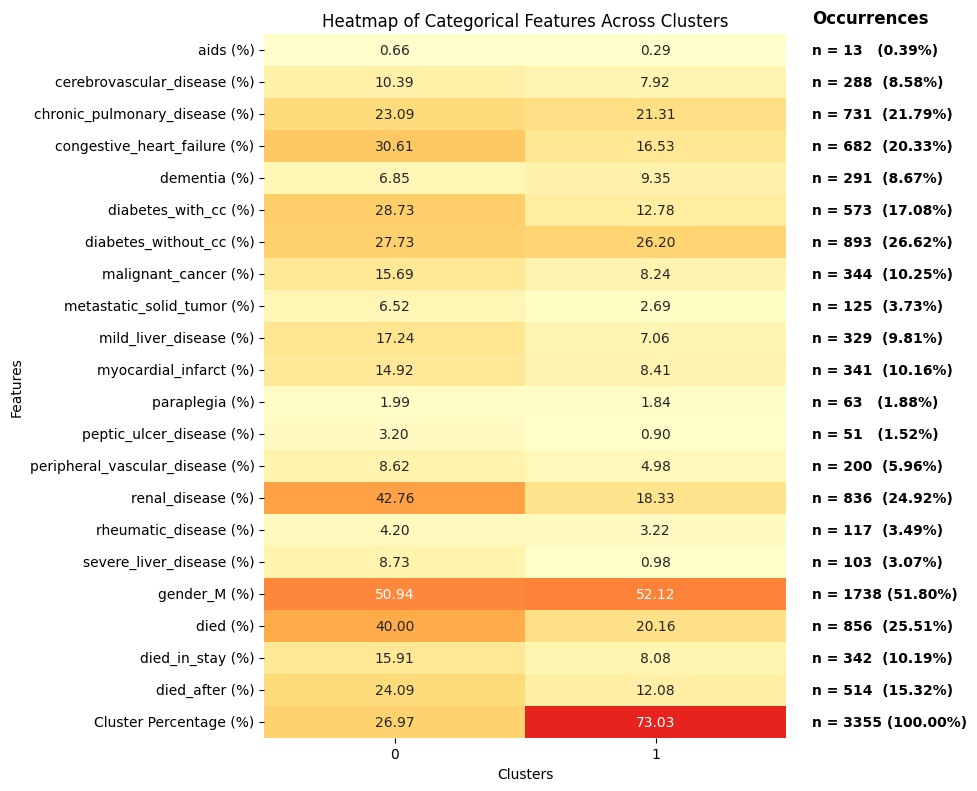

In [ ]:
mice_cluster =  helper.clustering(n_clusters=2, linkage_method="ward", dimensionality_reduction={"method": "PCA", "dimensions": 30})
helper.heatmapClustersCategorical(figsize=FIGSIZE_CLUSTER_HEATMAP, savepath=IMAGES_SAVE_PATH + "hierarchical-dr-pca-categorical")
# helper.showClusteredDataUMAP()

/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/v

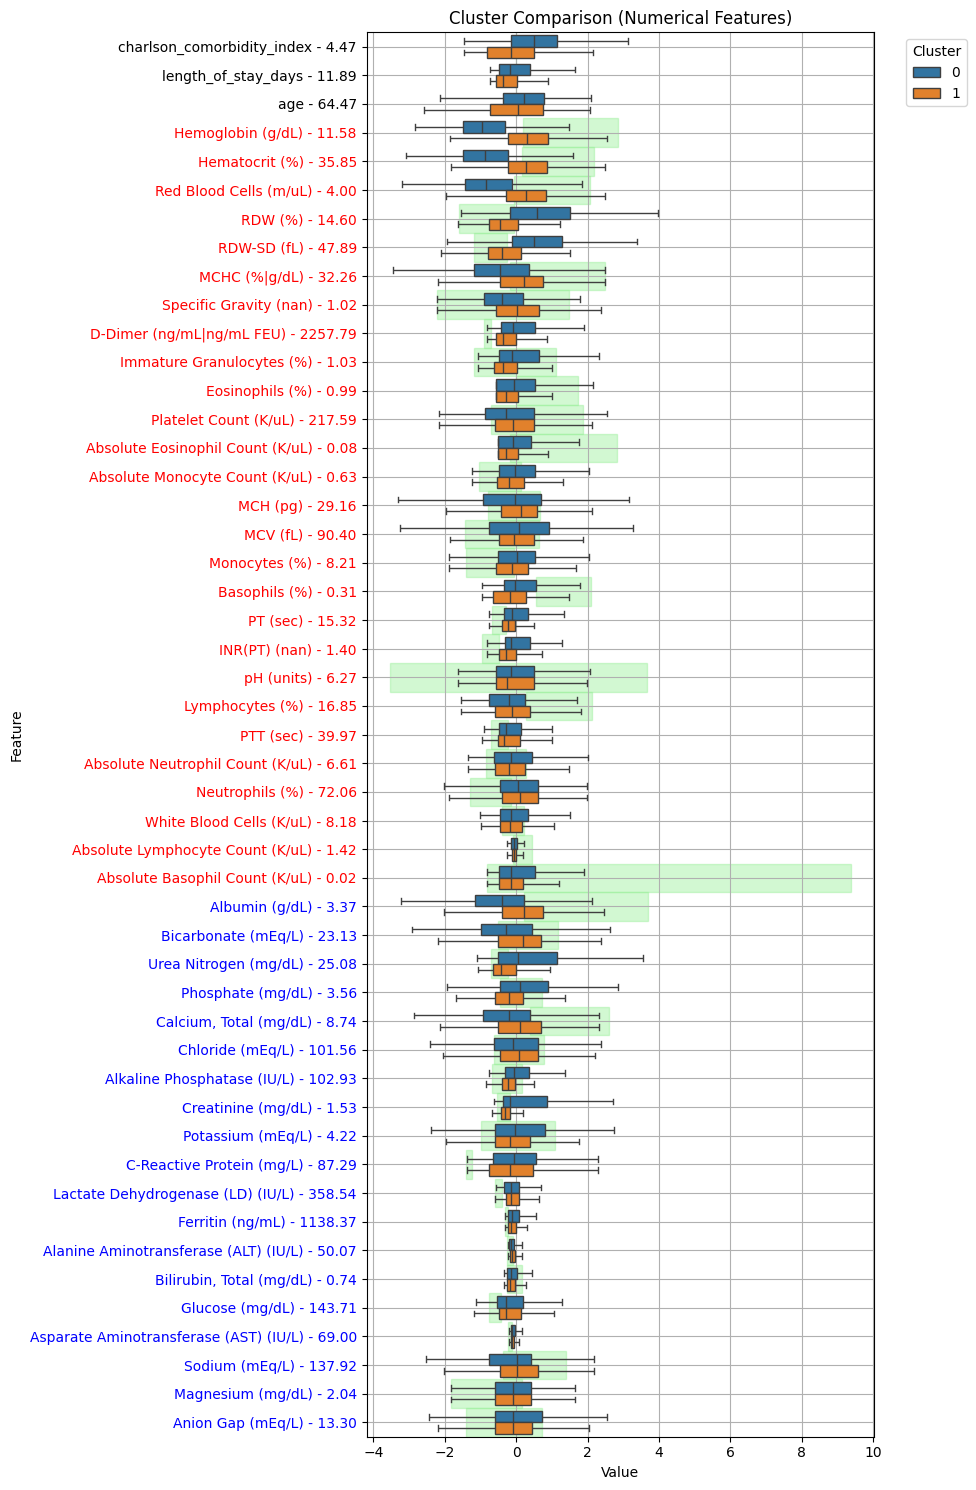

[]

In [ ]:
helper.showClusterCompareNumerical(
    scaled="standard",
    topFeatures=-1,
    max_features=-1,
    figsize=(10, 15),
    savepath=IMAGES_SAVE_PATH + "hierarchical-dr-pca-numerical",
    verbose=1
)

In [ ]:
selectedClusters = [0, 1]

In [ ]:
helper.setClusteredAutoencoder()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:24<00:00,  4.03it/s]


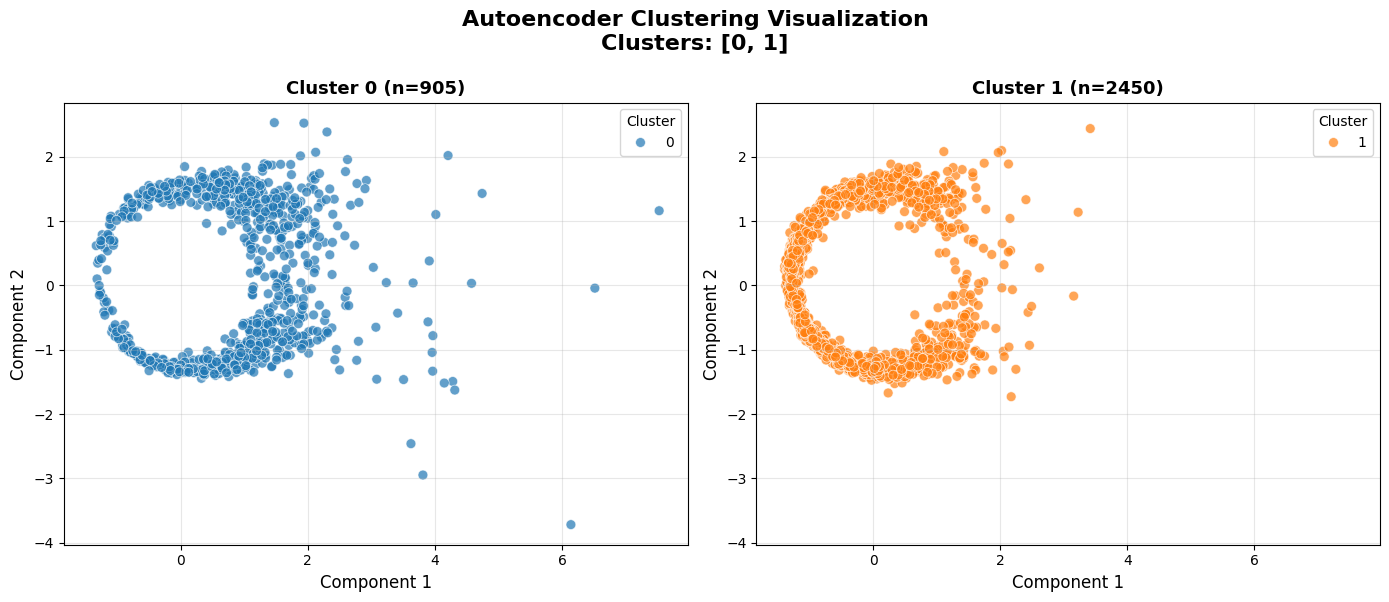

In [ ]:
helper.showClusteredAutoencoder(selectedClusters=selectedClusters, savepath=IMAGES_SAVE_PATH + "hierarchical-autoencoder-dr-pca")

##### Future data


/Users/gabrielleite/Backup/Mestrado/Mestrado-COVID/Modules/FutureAnalysisModule.py:35: UserWarning: Warning: Some subject_ids in futureData are missing from pastData.
  warnings.warn(


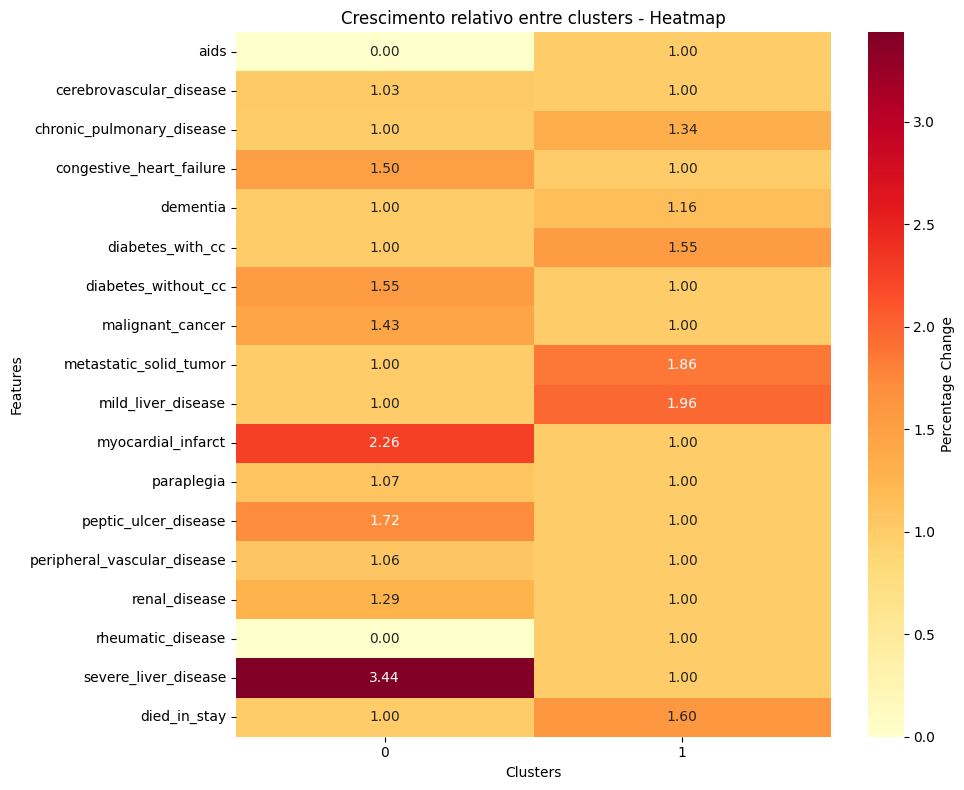

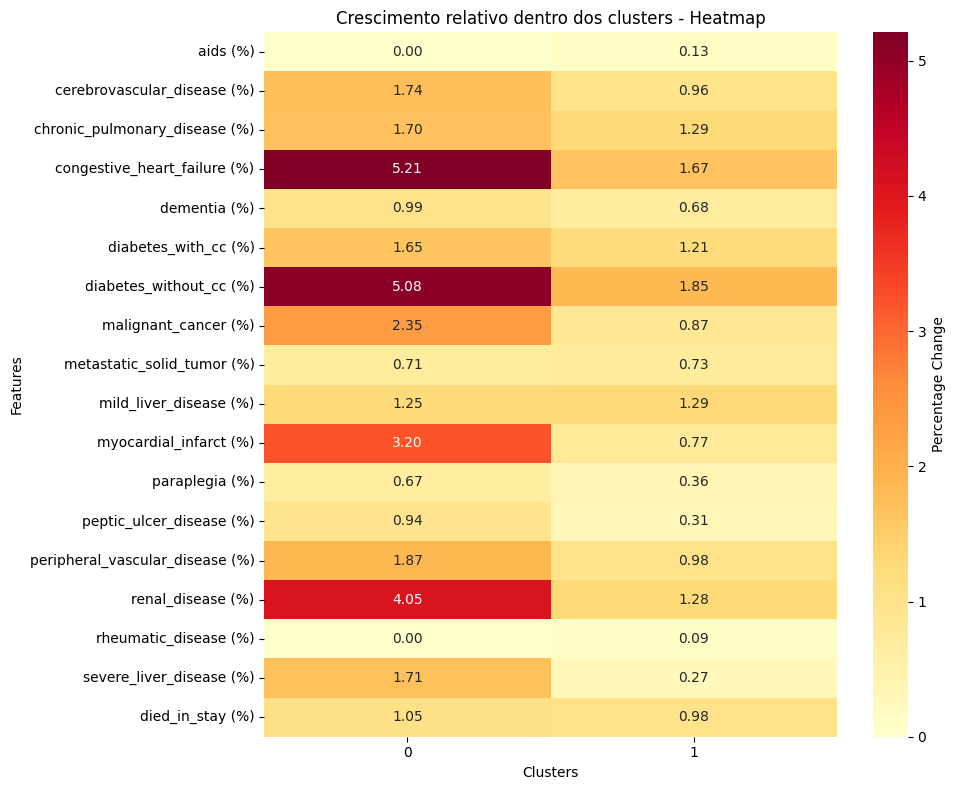

In [ ]:
future_helper = fa.FutureAnalysisHelper(helper.clusteredData, future_data)
future_helper.insertClustersInFutureData(onlyFirstAdmission=True)
delta = future_helper.getDeltaClusters(percentage=True, metric="externo")
future_helper.showDeltaHeatmap(
    figsize=FIGSIZE_FUTURE_HEATMAP,
    selectedClusters=selectedClusters,
    savepath=IMAGES_SAVE_PATH + "hierarchical-dr-pca-externo",
    metric="externo",
)
delta = future_helper.getDeltaClusters(percentage=True, metric="interno")
future_helper.showDeltaHeatmap(
    figsize=FIGSIZE_FUTURE_HEATMAP,
    selectedClusters=selectedClusters,
    savepath=IMAGES_SAVE_PATH + "hierarchical-dr-pca-interno",
    metric="interno",
)

In [ ]:
future_helper.getMeanReadmission()

{'Mean readmission Cluster 0': 2.65,
 'Mean readmission Cluster 1': 2.12,
 'Overall Mean readmission': 2.31}

In [ ]:
future_helper.getMeanDaysGap()

{'Mean days gap Cluster 0': 112.76,
 'Mean days gap Cluster 1': 136.05,
 'Overall Mean days gap': 127.49}

In [ ]:
future_helper.getMortalityRates(onlyFirstAdmission=True)

{'Mortality rate Cluster 0': 0.06,
 'Mortality rate Cluster 1': 0.11,
 'Overall Mortality rate': 0.09}

#### Add log

In [ ]:
log_file = "../log.csv"
current_dir = os.getcwd()
log_file_path = os.path.join(current_dir, log_file)

metrics = helper.getMetrics()

# Add line to save log
if os.path.exists(log_file_path):
    with open(log_file_path, 'a') as f:
        f.write(f"Hierarchical, PCA, Comprehensive, {metrics['disco']}, {metrics['dbcv']}, {metrics['dsi']}, {metrics['silhouette']}\n")

### Autoencoder - Ward - Euclidean

#### K = 2

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:25<00:00,  3.90it/s]


/Users/gabrielleite/Backup/Mestrado/Mestrado-COVID/Modules/ClusterBaseModule.py:259: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cluster_stats = self.__clusteredData.groupby("Cluster").apply(calculate_stats)
/Users/gabrielleite/Backup/Mestrado/Mestrado-COVID/Modules/ClusterBaseModule.py:1699: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.08 x' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annot_labels.loc[idx] = df.loc[idx].map(lambda x: f"{x:.2f} x")
/Users/gabrielleite/Backup/Mestrado/Mestrado-COVID/Modules/ClusterBaseModule.py:1699: FutureWarning: Setting an item of in

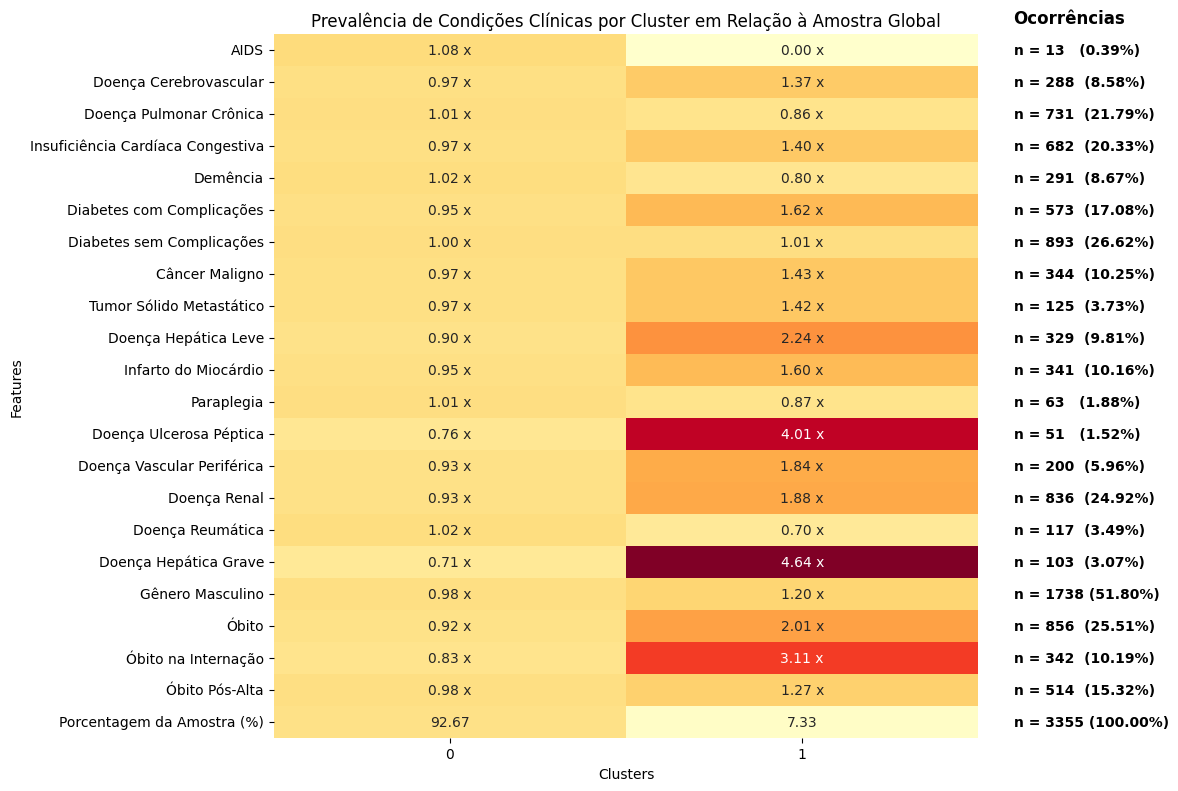

/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)


{'silhouette': 0.572,
 'dbcv': -0.9969750341001602,
 'dsi': np.float64(0.244),
 'disco': np.float64(0.7168681753813755)}

In [14]:
mice_cluster = helper.clustering(
    n_clusters=2,
    linkage_method="ward",
    dimensionality_reduction={"method": "AE", "dimensions": 10},
)
helper.heatmapClustersCategorical(
    figsize=FIGSIZE_CLUSTER_HEATMAP,
    relativeTotal=True,
    # savepath=IMAGES_SAVE_PATH + "hierarchical-ae-categorical-relative",
)
helper.getMetrics()

/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/v

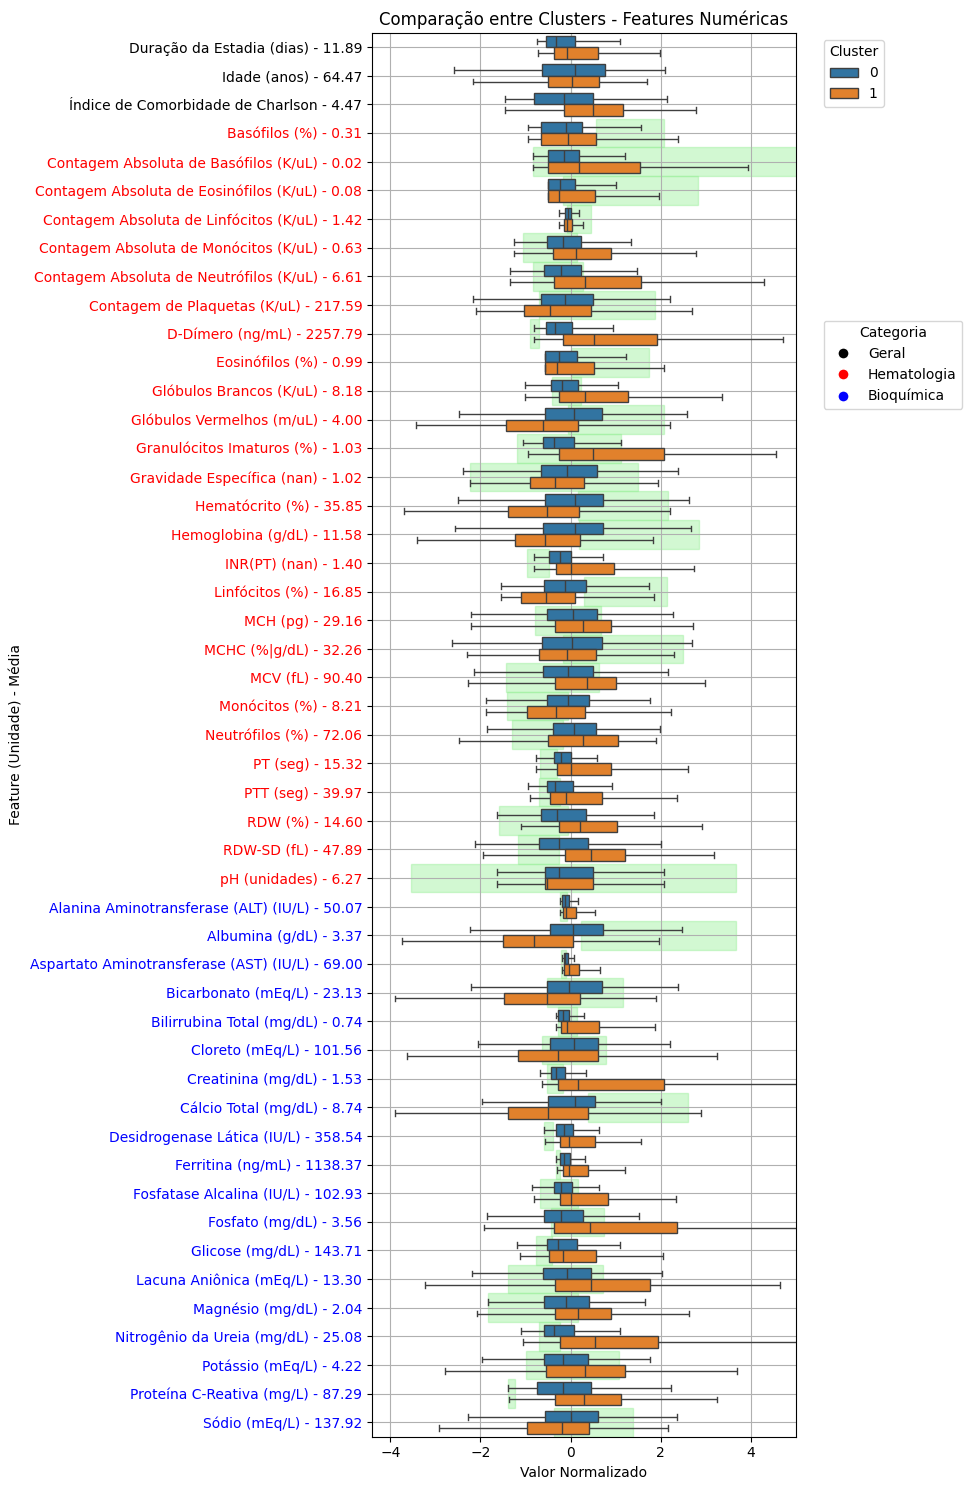

[('D-Dimer_Hematology_Blood_ng/mL|ng/mL FEU',
  np.float64(2.7248842896352254e-36)),
 ('Urea Nitrogen_Chemistry_Blood_mg/dL', np.float64(1.1723463747738996e-31)),
 ('Creatinine_Chemistry_Blood_mg/dL', np.float64(4.152896987233308e-31)),
 ('Immature Granulocytes_Hematology_Blood_%',
  np.float64(1.8879012998385145e-29)),
 ('Phosphate_Chemistry_Blood_mg/dL', np.float64(1.9976140333369528e-25)),
 ('White Blood Cells_Hematology_Blood_K/uL',
  np.float64(6.001367650825449e-23)),
 ('Albumin_Chemistry_Blood_g/dL', np.float64(2.359299818865004e-22)),
 ('RDW-SD_Hematology_Blood_fL', np.float64(2.719821199489676e-20)),
 ('Absolute Neutrophil Count_Hematology_Blood_K/uL',
  np.float64(5.23773667737277e-19)),
 ('INR(PT)_Hematology_Blood_nan', np.float64(5.513947378938806e-19)),
 ('PT_Hematology_Blood_sec', np.float64(3.2397540543406457e-18)),
 ('Asparate Aminotransferase (AST)_Chemistry_Blood_IU/L',
  np.float64(4.4088207126418566e-18)),
 ('Anion Gap_Chemistry_Blood_mEq/L', np.float64(8.0995213998

In [16]:
helper.showClusterCompareNumerical(
    scaled="standard",
    topFeatures=-1,
    max_features=-1,
    figsize=(10, 15),
    # savepath=IMAGES_SAVE_PATH + "hierarchical-ae-numerical",
)

In [17]:
selectedClusters = [0, 1]

In [18]:
helper.setClusteredAutoencoder()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:23<00:00,  4.21it/s]


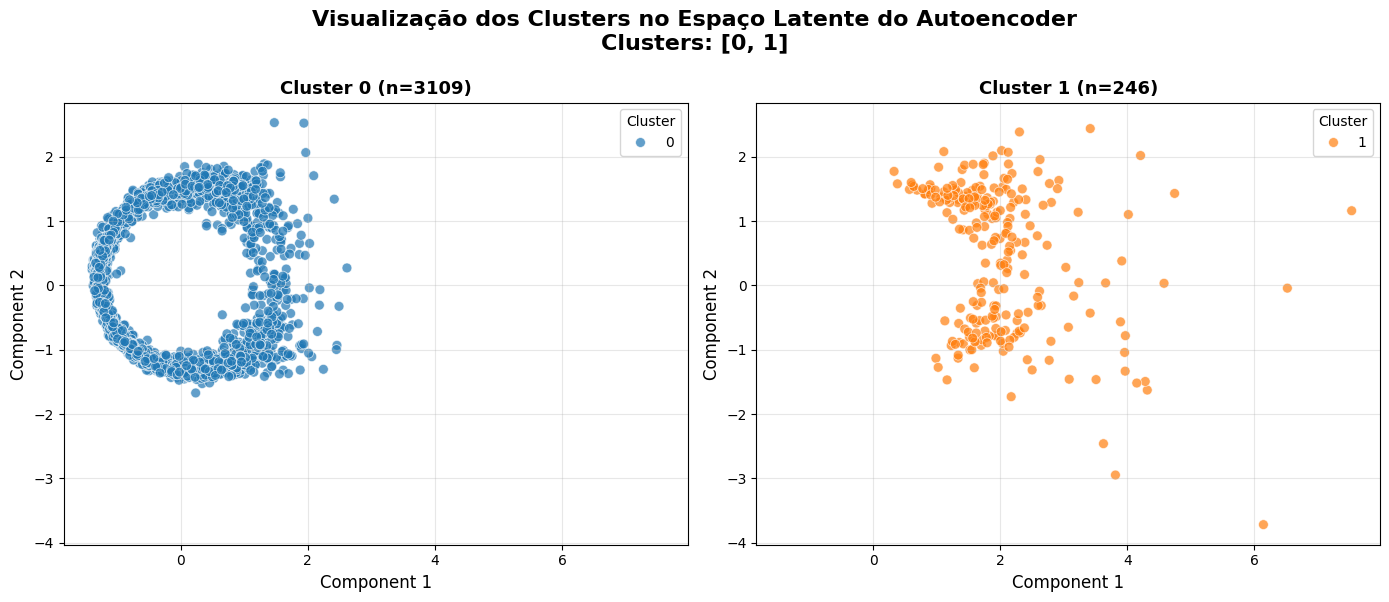

In [19]:
helper.showClusteredAutoencoder(
    selectedClusters=selectedClusters,
    # savepath=IMAGES_SAVE_PATH + "hierarchical-ae-autoencoder",
)

##### Future data


2026-01-30 14:00:22,500 - Modules.FutureAnalysisModule - WARNING - 84 subject_ids in target data are missing from reference data. These will be filtered out.
2026-01-30 14:00:22,505 - Modules.FutureAnalysisModule - WARNING - 551 subject_ids in target data are missing from reference data. These will be filtered out.
2026-01-30 14:00:22,528 - Modules.FutureAnalysisModule - INFO - Clusters inserted for 3649 records
2026-01-30 14:00:22,539 - Modules.FutureAnalysisModule - INFO - Auto-detected 19 binary features for analysis
2026-01-30 14:00:22,570 - Modules.FutureAnalysisModule - INFO - Delta clusters calculated for 1 clusters
2026-01-30 14:00:22,572 - Modules.FutureAnalysisModule - INFO - FutureAnalysisHelper initialized with 3355 past records and 2257 future records
2026-01-30 14:00:22,577 - Modules.FutureAnalysisModule - INFO - Clusters inserted for 976 records
2026-01-30 14:00:22,581 - Modules.FutureAnalysisModule - INFO - Auto-detected 20 binary features for analysis
2026-01-30 14:00:

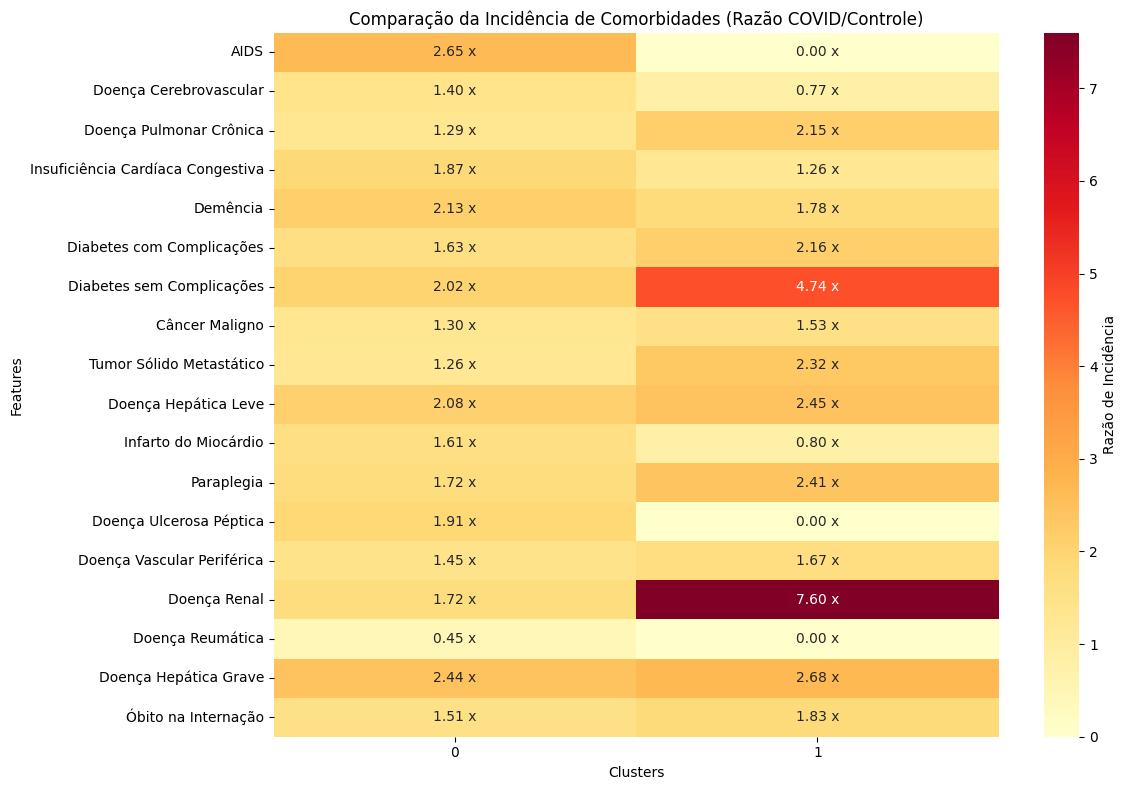

In [20]:
future_helper = fa.FutureAnalysisHelper(
    helper.clusteredData, future_data, control, control_readmission
)
delta = future_helper.get_delta_clusters(percentage=True, relative_total=True)
future_helper.show_delta_heatmap(
    figsize=FIGSIZE_FUTURE_HEATMAP,
    relative_total=True,
    selected_clusters=selectedClusters,
    # savepath=IMAGES_SAVE_PATH + "hierarchical-ae-future",
)

In [ ]:
future_helper.getMeanReadmission()

{'Mean readmission Cluster 0': 2.33,
 'Mean readmission Cluster 1': 2.05,
 'Overall Mean readmission': 2.31}

In [ ]:
future_helper.getMeanDaysGap()

{'Mean days gap Cluster 0': 128.75,
 'Mean days gap Cluster 1': 110.0,
 'Overall Mean days gap': 127.49}

In [ ]:
future_helper.getMortalityRates(onlyFirstAdmission=True)

{'Mortality rate Cluster 0': 0.11,
 'Mortality rate Cluster 1': 0.03,
 'Overall Mortality rate': 0.09}

#### Add log

In [ ]:
log_file = "../log.csv"
current_dir = os.getcwd()
log_file_path = os.path.join(current_dir, log_file)

metrics = helper.getMetrics()

# Add line to save log
if os.path.exists(log_file_path):
    with open(log_file_path, 'a') as f:
        f.write(f"Hierarchical, Autoencoder, Comprehensive, {metrics['disco']}, {metrics['dbcv']}, {metrics['dsi']}, {metrics['silhouette']}\n")